In [92]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [135]:
# Simple NN: u(r,theta) -> scalar
class Net(nn.Module):
    def __init__(self, layers=(2, 20, 1)):
        super().__init__()
        net = []
        for i in range(len(layers) - 2):  # hidden layers
            net.append(nn.Linear(layers[i], layers[i+1]))
            net.append(nn.Tanh())
        net.append(nn.Linear(layers[-2], layers[-1]))  # output layer
        self.net = nn.Sequential(*net)
    def forward(self, r, theta):  # force the neural network to think in Cartesian coordinates
        # Coordinate embedding: (r, theta) -> (x, y) to enforce geometric continuity.
        x = r * torch.cos(theta)
        y = r * torch.sin(theta)
        X = torch.cat([x, y], dim=1) # Network sees x,y
        return self.net(X)

Dirichlet problem for the Laplace equation in a disk in a polar coordinates:
$D = \{0 \le r < 1, \; -\pi < \theta < \pi\},$
$$
\begin{cases}
    \Delta u = -r^2 & \text{in } D \\
    u(1, \theta) = 0 & \text{ on } \partial D
\end{cases}
$$

With a solution $u(r, \theta) = \frac{1}{16} (1 - r^2) (r^2 + 1)$

In [110]:
# --- Collocation points ---
N_f = 500  # number of collocation points
r_f = torch.rand(N_f, 1)
r_f.requires_grad_()
theta_f = (torch.rand(N_f, 1) - 0.5) * 2 * math.pi  # so it is in range (-pi, pi)
theta_f.requires_grad_()
u_exact = (1/16 *(1 - torch.pow(r_f, 2)) * (torch.pow(r_f, 2) + 1)).detach()
f = (-torch.pow(r_f, 2)).detach()

# --- Boundary points r = 1 ---
N_bc = 250
r_bc = torch.full((N_bc, 1), 1.0)
theta_bc = 2 * math.pi * torch.rand(N_bc, 1) - math.pi  # so it is in range (-pi, pi)

In [112]:
net = Net((2, 20, 50, 100, 50, 20, 1))

optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)  # SGD (Stochastic Gradient Descent) with Momentum
# optimizer = optim.Adam(net.parameters(), lr=1e-3)

"""scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.8,
    patience=30
)"""


mse_errors = []
l2_errors = []
l2_relative_errors = []
lrs = []

for epoch in range(6001):
    optimizer.zero_grad()

    # PDE residual
    u_f = net(r_f, theta_f)
    u_theta = torch.autograd.grad(u_f.sum(), theta_f, create_graph=True)[0]
    u_r = torch.autograd.grad(u_f.sum(), r_f ,create_graph=True)[0]

    u_theta2 = torch.autograd.grad(u_theta, theta_f, torch.ones_like(u_theta), create_graph=True)[0]
    u_rr = torch.autograd.grad(u_r, r_f, torch.ones_like(u_r), create_graph=True)[0]
    # around r=0 terms 1/r and 1/r^2 become massive causing noisy loss values near the center
    # to avoid it, division by r^2 should be avoided
    f_res = torch.pow(r_f, 2) * u_rr + r_f * u_r + u_theta2
    loss_pde = torch.mean((f_res - f * torch.pow(r_f, 2))**2)

    # Boundary loss r=1
    u_bc_pred = net(r_bc, theta_bc)
    loss_bc = torch.mean(u_bc_pred** 2)


    loss = loss_pde + loss_bc
    loss.backward()
    optimizer.step()
    # scheduler.step(loss.detach())

    l2_errors.append(torch.norm(u_f - u_exact).detach().item())
    l2_relative_errors.append(torch.norm(u_f - u_exact).detach().item() / torch.norm(u_exact).detach().item())
    mse_errors.append(torch.mean((u_f - u_exact) ** 2).detach().item())
    lrs.append(optimizer.param_groups[0]['lr'])

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 0.122649
Epoch 1000, Loss: 0.009036
Epoch 2000, Loss: 0.000681
Epoch 3000, Loss: 0.000049
Epoch 4000, Loss: 0.000033
Epoch 5000, Loss: 0.000027
Epoch 6000, Loss: 0.000023


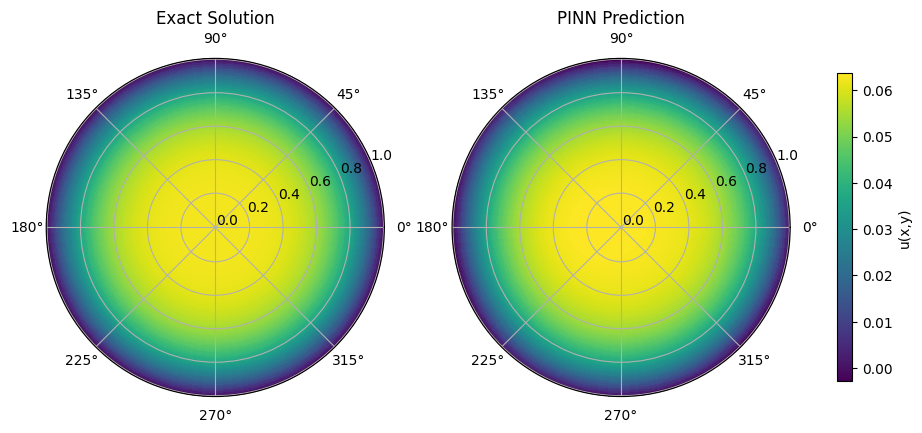

In [113]:
r_test = torch.linspace(0, 1, 100)
theta_test = torch.linspace(-math.pi, math.pi, 100)
R,Theta = torch.meshgrid(r_test, theta_test)
# (R[i,j], Theta[i,j]) is the coordinate of the (i,j) point in the 2D (r,theta) domain.
R_flat = R.reshape(-1,1)
Theta_flat = Theta.reshape(-1,1)

with torch.no_grad():
    u_pred = net(R_flat, Theta_flat).reshape(100, 100)
    u_exact = (1/16 *(1 - torch.pow(R_flat, 2)) * (torch.pow(R_flat, 2) + 1)).reshape(100, 100)

vmin_val = min(u_exact.min(), u_pred.min())
vmax_val = max(u_exact.max(), u_pred.max())

# Create 1x2 polar subplots
fig, axes = plt.subplots(1, 2, subplot_kw={'projection':'polar'}, figsize=(12,5))

# First polar heatmap
c1 = axes[0].pcolormesh(Theta, R, u_exact, shading='auto', cmap='viridis', vmin=vmin_val, vmax=vmax_val)
# fig.colorbar(c1, ax=axes[0], orientation='vertical', label='U(r,theta)')
axes[0].set_title("Exact Solution")

# Second polar heatmap
c2 = axes[1].pcolormesh(Theta, R, u_pred, shading='auto', cmap='viridis', vmin=vmin_val, vmax=vmax_val)
# fig.colorbar(c2, ax=axes[1], orientation='vertical', label='U(r,theta)')
axes[1].set_title("PINN Prediction")

# Single Colorbar
cbar = fig.colorbar(c1, ax=axes.ravel().tolist(), orientation='vertical', shrink=0.8)
cbar.set_label('u(x,y)')

plt.show()


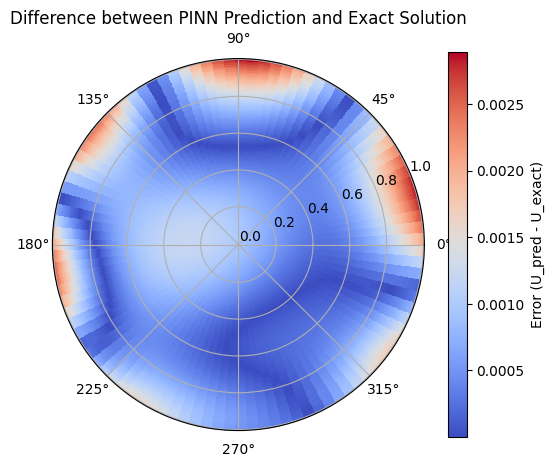

In [114]:
# Plot in a single polar subplot
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': 'polar'}, figsize=(6,5))

c = ax.pcolormesh(Theta, R, abs(u_exact - u_pred), shading='auto', cmap='coolwarm')  # coolwarm shows +/− nicely
fig.colorbar(c, ax=ax, orientation='vertical', label='Error (U_pred - U_exact)')
ax.set_title("Difference between PINN Prediction and Exact Solution")

plt.show()

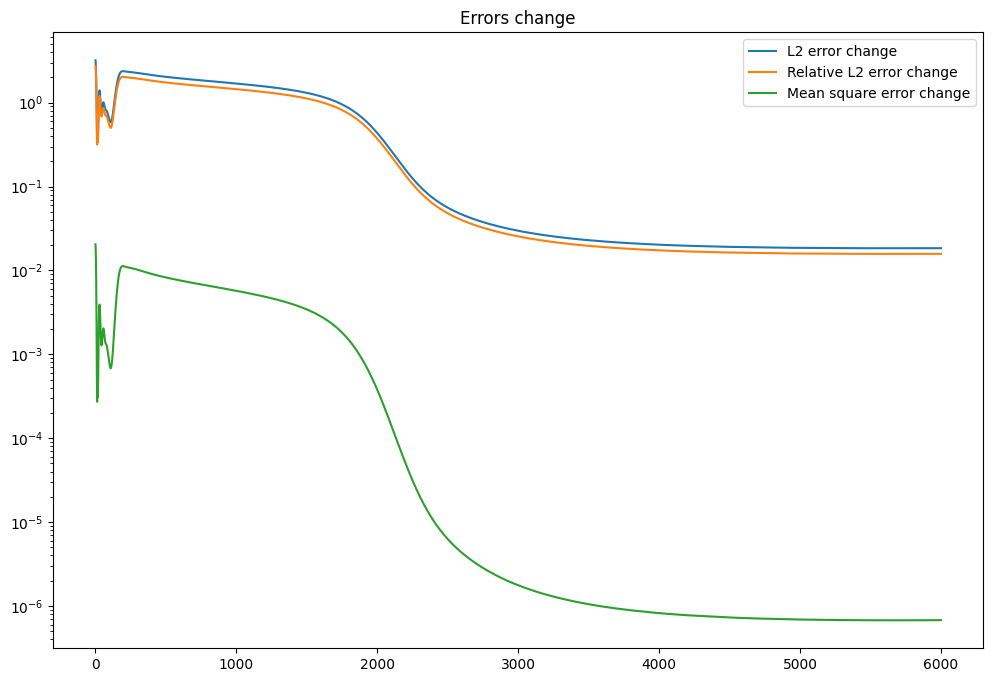

Minimum mean square error: 6.747018232999835e-07
Minimum l2 error: 0.018367115408182144
Minimum relative l2 error: 0.01572804413992168


In [115]:
plt.figure(figsize=(12,8))

# plt.subplot(2,1,1)
plt.semilogy(np.arange(0, 6001), l2_errors, label="L2 error change")
plt.semilogy(np.arange(0, 6001), l2_relative_errors, label="Relative L2 error change")
plt.semilogy(np.arange(0, 6001), mse_errors, label="Mean square error change")
plt.legend()
plt.title('Errors change')
"""
plt.subplot(2,1,2)
plt.semilogy(np.arange(0, 6001), lrs, label="L2 error change")
plt.title('Learning rate change')
"""
plt.show()
print(f"Minimum mean square error: {min(mse_errors)}")
print(f"Minimum l2 error: {min(l2_errors)}")
print(f"Minimum relative l2 error: {min(l2_relative_errors)}")

Now we consider the same issue but in cartesian coordinates
$D = \{(x, y) \in \mathbb{R}^2 \mid x^2 + y^2 < 1\}$
$$
\begin{cases}
    \Delta u = -(x^2 + y^2) & \text{in } D \\
    u(1, \theta) = 0 & \text{ on } \partial D
\end{cases}
$$

With a solution $u(r, \theta) = \frac{1}{16} (1 - x^2 + y^2) (x^2 + y^2 + 1)$

This approach solves 2 issues:
- no singularity around $r=0$
- no periodicity issue (network did not understand that $-\pi$ and $\pi$ are the same)

In [142]:
# Simple NN: u(x,y) -> scalar
class Net(nn.Module):
    def __init__(self, layers=(2, 20, 1)):
        super().__init__()
        net = []
        for i in range(len(layers) - 2):  # hidden layers
            net.append(nn.Linear(layers[i], layers[i+1]))
            net.append(nn.Tanh())
        net.append(nn.Linear(layers[-2], layers[-1]))  # output layer
        self.net = nn.Sequential(*net)
    def forward(self, x, y):  # force the neural network to think in Cartesian coordinates
        X = torch.cat([x, y], dim=1) # Network sees x,y
        return self.net(X)

In [143]:
# --- Collocation points ---
N_f = 500  # number of collocation points
r_f = torch.rand(N_f, 1)
theta_f = (torch.rand(N_f, 1) - 0.5) * 2 * math.pi
x_f = r_f * torch.cos(theta_f)
y_f = r_f * torch.sin(theta_f)
x_f.requires_grad_()
y_f.requires_grad_()

u_exact = (1/16 *(1 - torch.pow(x_f, 2) - torch.pow(y_f, 2)) * (torch.pow(r_f, 2) + - torch.pow(y_f, 2) + 1)).detach()
f = (-torch.pow(x_f, 2) - torch.pow(y_f, 2)).detach()

# --- Boundary points on unit circle ---
N_bc = 250
theta_bc = 2 * math.pi * torch.rand(N_bc, 1) - math.pi  # so it is in range (-pi, pi)
x_bc = torch.cos(theta_bc)
y_bc = torch.sin(theta_bc)

In [144]:
net = Net((2, 20, 50, 100, 50, 20, 1))

optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)  # SGD (Stochastic Gradient Descent) with Momentum
# optimizer = optim.Adam(net.parameters(), lr=1e-3)

"""scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.8,
    patience=30
)"""


mse_errors = []
l2_errors = []
l2_relative_errors = []
lrs = []

for epoch in range(6001):
    optimizer.zero_grad()

    # PDE residual
    u_f = net(x_f, y_f)
    u_x = torch.autograd.grad(u_f.sum(), x_f, create_graph=True)[0]
    u_y = torch.autograd.grad(u_f.sum(), y_f ,create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x_f, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y_f, torch.ones_like(u_y), create_graph=True)[0]
    f_res = u_xx + u_yy
    loss_pde = torch.mean((f_res - f)**2)

    # Boundary loss r=1
    u_bc_pred = net(x_bc, y_bc)
    loss_bc = torch.mean(u_bc_pred** 2)

    loss = loss_pde + loss_bc
    loss.backward()
    optimizer.step()
    # scheduler.step(loss.detach())

    l2_errors.append(torch.norm(u_f - u_exact).detach().item())
    l2_relative_errors.append(torch.norm(u_f - u_exact).detach().item() / torch.norm(u_exact).detach().item())
    mse_errors.append(torch.mean((u_f - u_exact) ** 2).detach().item())
    lrs.append(optimizer.param_groups[0]['lr'])

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 0.250189
Epoch 1000, Loss: 0.001569
Epoch 2000, Loss: 0.000468
Epoch 3000, Loss: 0.000205
Epoch 4000, Loss: 0.000111
Epoch 5000, Loss: 0.000073
Epoch 6000, Loss: 0.000055


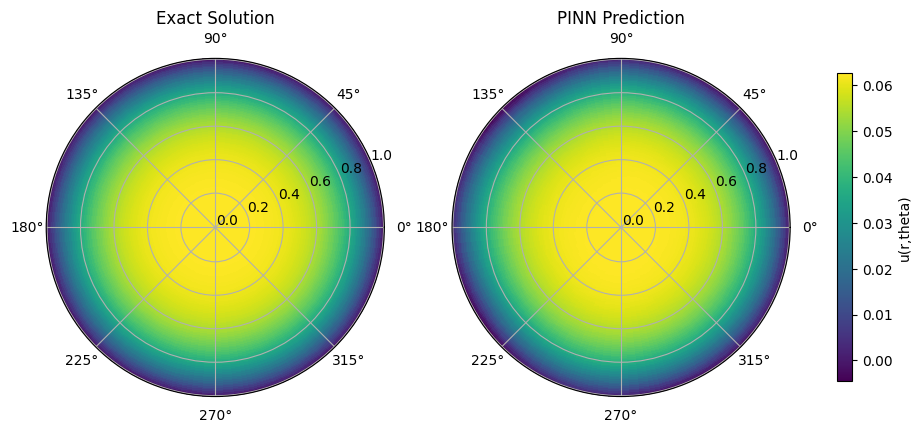

In [145]:
r_test = torch.linspace(0, 1, 100)
theta_test = torch.linspace(-math.pi, math.pi, 100)
R, Theta = torch.meshgrid(r_test, theta_test, indexing='ij')
R_flat = R.reshape(-1, 1)
Theta_flat = Theta.reshape(-1, 1)

X_flat = R_flat * torch.cos(Theta_flat)
Y_flat = R_flat * torch.sin(Theta_flat)

with torch.no_grad():
    u_pred = net(X_flat, Y_flat).reshape(100, 100)
    u_exact = (1/16 * (1 - torch.pow(R_flat, 2)) * (torch.pow(R_flat, 2) + 1)).reshape(100, 100)


# Create 1x2 polar subplots
fig, axes = plt.subplots(1, 2, subplot_kw={'projection':'polar'}, figsize=(12,5))
vmin_val = min(u_exact.min(), u_pred.min())
vmax_val = max(u_exact.max(), u_pred.max())

# First polar heatmap
c1 = axes[0].pcolormesh(Theta, R, u_exact, shading='auto', cmap='viridis', vmin=vmin_val, vmax=vmax_val)
axes[0].set_title("Exact Solution")

# Second polar heatmap
c2 = axes[1].pcolormesh(Theta, R, u_pred, shading='auto', cmap='viridis', vmin=vmin_val, vmax=vmax_val)
axes[1].set_title("PINN Prediction")
# Single Colorbar
cbar = fig.colorbar(c1, ax=axes.ravel().tolist(), orientation='vertical', shrink=0.8)
cbar.set_label('u(r,theta)')

plt.show()

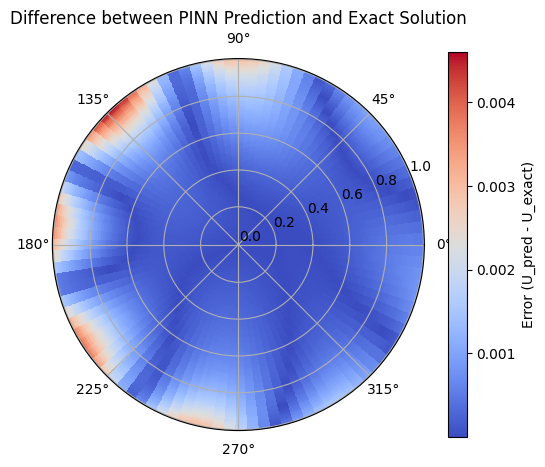

In [146]:
# Plot in a single polar subplot
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': 'polar'}, figsize=(6,5))

c = ax.pcolormesh(Theta, R, abs(u_exact - u_pred), shading='auto', cmap='coolwarm')  # coolwarm shows +/− nicely
fig.colorbar(c, ax=ax, orientation='vertical', label='Error (U_pred - U_exact)')
ax.set_title("Difference between PINN Prediction and Exact Solution")

plt.show()

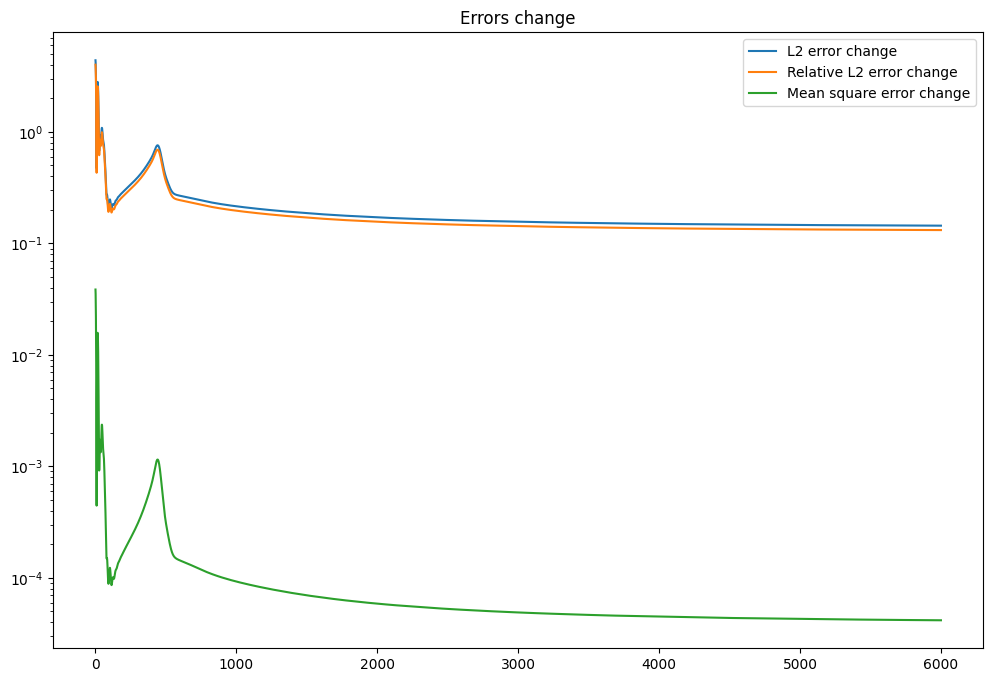

Minimum mean square error: 4.166199141764082e-05
Minimum l2 error: 0.14432945847511292
Minimum relative l2 error: 0.13174273565441433


In [147]:
plt.figure(figsize=(12,8))

# plt.subplot(2,1,1)
plt.semilogy(np.arange(0, 6001), l2_errors, label="L2 error change")
plt.semilogy(np.arange(0, 6001), l2_relative_errors, label="Relative L2 error change")
plt.semilogy(np.arange(0, 6001), mse_errors, label="Mean square error change")
plt.legend()
plt.title('Errors change')
"""
plt.subplot(2,1,2)
plt.semilogy(np.arange(0, 6001), lrs, label="L2 error change")
plt.title('Learning rate change')
"""
plt.show()
print(f"Minimum mean square error: {min(mse_errors)}")
print(f"Minimum l2 error: {min(l2_errors)}")
print(f"Minimum relative l2 error: {min(l2_relative_errors)}")